In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

In [2]:
df = pd.read_csv('Feature Engineered IMDB Dataset.csv')

In [3]:
df.head()

,Unnamed: 0.1,Unnamed: 0,review,sentiment,cleaned_review,tokenized_review,stemmed review,filtered review,feature word count,sentence length,feature punctuation frequency,feature readability,most_frequent_terms,feature_real_word_ratio
0,0,0,One of the other reviewers has mentioned that ...,positive,one of the other reviewers has mentioned that ...,"['one', 'of', 'the', 'other', 'reviewers', 'ha...","['one', 'of', 'the', 'other', 'review', 'has',...","['review', 'mention', 'watch', '1', 'oz', 'epi...",307,1761,43,66.152200,"['oz', 'violenc', 'watch']",0.832237
1,1,1,A wonderful little production. <br /><br />The...,positive,a wonderful little production the filming tec...,"['a', 'wonderful', 'little', 'production', 'th...","['a', 'wonder', 'littl', 'product', 'the', 'fi...","['wonder', 'littl', 'product', 'film', 'techni...",162,998,16,45.478333,"['littl', 'product', 'techniqu']",0.826923
2,2,2,I thought this was a wonderful way to spend ti...,positive,i thought this was a wonderful way to spend ti...,"['i', 'thought', 'this', 'was', 'a', 'wonderfu...","['i', 'thought', 'this', 'was', 'a', 'wonder',...","['thought', 'wonder', 'way', 'spend', 'time', ...",166,926,23,57.459357,"['comedi', 'thought', 'woodi']",0.908537
3,3,3,Basically there's a family where a little boy ...,negative,basically theres a family where a little boy j...,"['basically', 'theres', 'a', 'family', 'where'...","['basic', 'there', 'a', 'famili', 'where', 'a'...","['basic', 'famili', 'littl', 'boy', 'jake', 't...",138,748,24,75.319167,"['jake', 'parent', 'movi']",0.863636
4,4,4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,petter matteis love in the time of money is a ...,"['petter', 'matteis', 'love', 'in', 'the', 'ti...","['petter', 'mattei', 'love', 'in', 'the', 'tim...","['petter', 'mattei', 'love', 'time', 'money', ...",230,1317,34,60.138177,"['mattei', 'mr', 'peopl']",0.893333


In [14]:
# Converting the 'filtered review' list of tokens back into strings for the Vectorizer
X_text = df['filtered review'].apply(lambda x:" ".join(x) if isinstance(x, list) else str(x))
y = df['sentiment']
# Fitting the vectorizer and a fast Logistic Regression Model
tfidf = TfidfVectorizer(max_features = 5000)
X_words = tfidf.fit_transform(X_text)
model = LogisticRegression()
model.fit(X_words, y)
# Pairing the words with their model weights
feature_names = tfidf.get_feature_names_out()
coefficients = model.coef_.flatten()
importance_df = pd.DataFrame({'Feature':feature_names, "Coefficient": coefficients})

C:\Users\rashm\AppData\Local\Temp\ipykernel_43208\1967187733.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data = top_features, palette=colour)


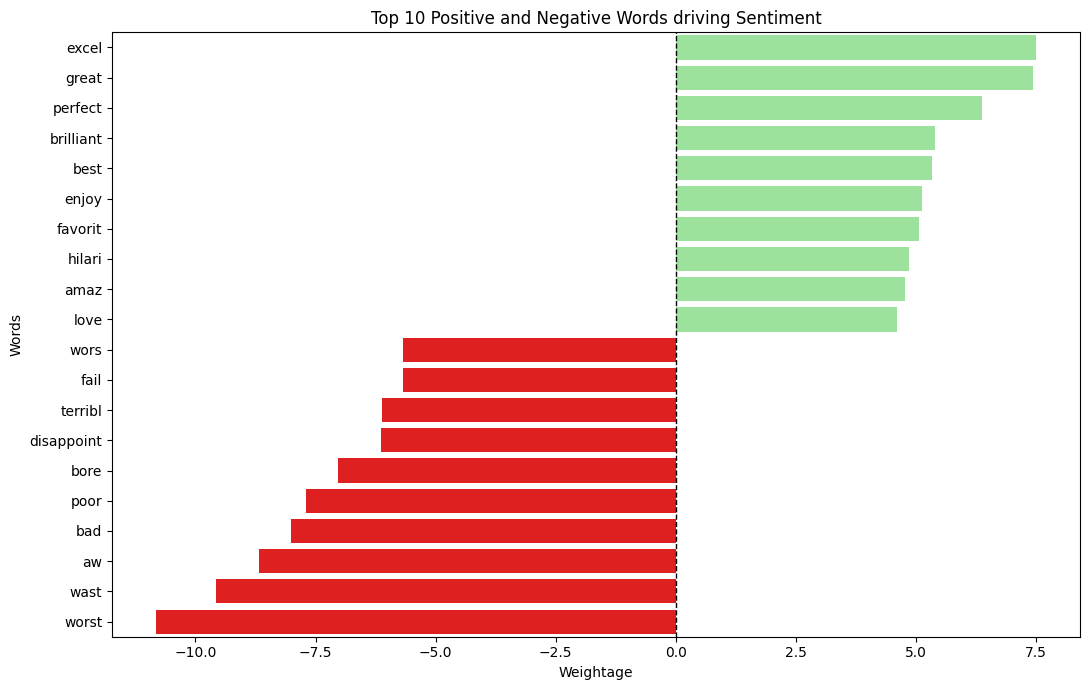

In [20]:
# Considering the top 10 positive and top 10 negative words 
top_pos = importance_df.sort_values(by = 'Coefficient', ascending = False).head(10)
top_neg = importance_df.sort_values(by = 'Coefficient', ascending = True).head(10)
top_features = pd.concat([top_pos, top_neg]).sort_values(by='Coefficient', ascending = False)
# Plotting
plt.figure(figsize = (11,7))
colour = ['lightgreen' if c>0 else 'red' for c in top_features['Coefficient']]
sns.barplot(x='Coefficient', y='Feature', data = top_features, palette=colour) 
plt.axvline(x=0, color = 'black', linestyle='--', linewidth=1)
plt.title('Top 10 Positive and Negative Words driving Sentiment')
plt.xlabel('Weightage')
plt.ylabel('Words')
plt.tight_layout()
plt.show()

In [9]:
# Feature Comparison
from sklearn.feature_extraction.text import CountVectorizer
represent = {'BoW':CountVectorizer(max_features= 5000), 'BiGrams':CountVectorizer(ngram_range=(2,2),max_features = 5000), 'TriGrams': CountVectorizer(ngram_range=(3,3), max_features=5000), 'TfIdf':TfidfVectorizer(max_features=5000)}

In [16]:
from sklearn.metrics import accuracy_score, f1_score
results = []

In [17]:
for name, vectorizer in represent.items():
    # Generating feature matrix for each
    X_features = vectorizer.fit_transform(X_text)
    # Split into Train/Test matrices (80/20)
    X_train, X_test, y_train, y_test = train_test_split(X_features, y, test_size=0.2, random_state=42, stratify=y)
    # Training the classifier
    clf = LogisticRegression(max_iter=1000)
    clf.fit(X_train, y_train)
    # Making predictions and evaluate
    preds = clf.predict(X_test)
    acc = accuracy_score(y_test, preds)
    # Adjusting pos_label if needed
    f1 = f1_score(y_test, preds, pos_label='positive') 
    # Saving statistics
    results.append({
        'Representation': name,
        'Accuracy': acc,
        'F1-Score': f1
    })

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

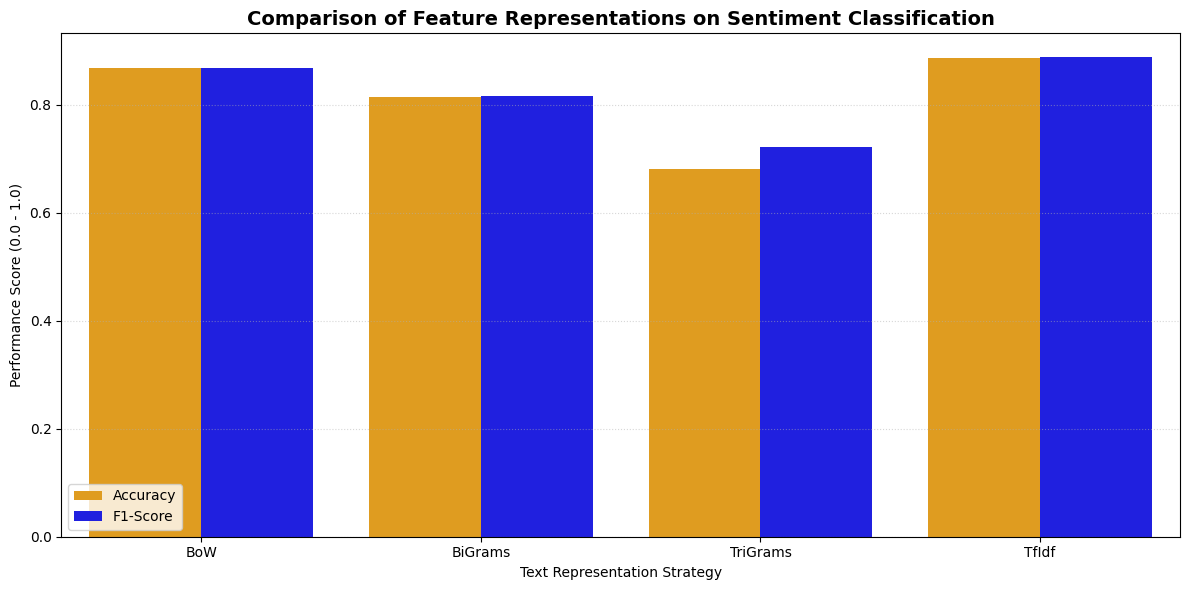

In [19]:
# Transforming the DataFrame to make it compatible with Seaborn's grouping
performance_df = pd.DataFrame(results)
plot_data = performance_df.melt(id_vars='Representation', value_vars=['Accuracy', 'F1-Score'], var_name='Metric', value_name='Score')
plt.figure(figsize=(12, 6))
sns.barplot(x='Representation', y='Score', hue='Metric', data=plot_data, palette=['orange', 'blue'])
plt.title('Comparison of Feature Representations on Sentiment Classification', fontsize=14, fontweight='bold')
plt.ylabel('Performance Score (0.0 - 1.0)')
plt.xlabel('Text Representation Strategy')
plt.grid(axis='y', linestyle=':', alpha=0.5)
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()